In [1]:
# import neccesary libraries
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')




In [2]:
# import the dataset
df = pd.read_csv("ESG_Data.csv", parse_dates=['Date'])


In [3]:
df

,Date,Year,Asset_ID,Asset_Type,Location,Operational_Status,Energy_Type,Consumption_Units,Emission_Type,Emissions_tCO2e,Target_Emissions_tCO2e,Reduction_Percentage_vs_BaseYear
0,2020-01-01,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2357.044,Scope 1,0.645377,15004.345,0.00
1,2020-01-01,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2357.044,Scope 2,0.530871,15004.345,0.00
2,2020-01-02,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2440.574,Scope 1,0.688000,15004.345,0.00
3,2020-01-02,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2440.574,Scope 2,0.572372,15004.345,0.00
4,2020-01-03,2020,A001,ServiceHub,England,Active,ELECTRICITY_KWH,2396.825,Scope 1,0.715998,15004.345,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
236731,2025-12-29,2025,A018,Depot,England,Active,DIESEL_L,220.770,Scope 2,0.140224,11307.747,24.64
236732,2025-12-30,2025,A018,Depot,England,Active,DIESEL_L,186.620,Scope 1,0.699935,11307.747,24.64
236733,2025-12-30,2025,A018,Depot,England,Active,DIESEL_L,186.620,Scope 2,0.149179,11307.747,24.64
236734,2025-12-31,2025,A018,Depot,England,Active,DIESEL_L,155.839,Scope 1,0.593795,11307.747,24.64


### Understanding the dataset

In [4]:
# check the shape of the dataset
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset has 236736 rows and 12 columns.


In [5]:
# check the date range of the dataset and missing values with the data info
print(f"date range: {df['Date'].min()} to {df['Date'].max()}\n")
print(f"data info:{df.info()}")
print(f"missing values:\n{df.isnull().sum()}")

date range: 2020-01-01 00:00:00 to 2025-12-31 00:00:00

<class 'pandas.DataFrame'>
RangeIndex: 236736 entries, 0 to 236735
Data columns (total 12 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   Date                              236736 non-null  datetime64[us]
 1   Year                              236736 non-null  int64         
 2   Asset_ID                          236736 non-null  str           
 3   Asset_Type                        236736 non-null  str           
 4   Location                          236736 non-null  str           
 5   Operational_Status                236736 non-null  str           
 6   Energy_Type                       236736 non-null  str           
 7   Consumption_Units                 236736 non-null  float64       
 8   Emission_Type                     236736 non-null  str           
 9   Emissions_tCO2e                   236736 non-null  float64

In [6]:
# check for duplicates
print(f"number of duplicate rows: {df.duplicated().sum()}")

number of duplicate rows: 0


In [7]:
# check duplicates based on the combination of 'Date' and 'Security' columns
print(f"number of duplicate rows based on 'Date' and 'Security': {df.duplicated(subset=['Date', 'Asset_ID', 'Energy_Type']).sum()}")

number of duplicate rows based on 'Date' and 'Security': 118368


In [8]:
# checking for Emission_Type values
df['Emission_Type']

0         Scope 1
1         Scope 2
2         Scope 1
3         Scope 2
4         Scope 1
           ...   
236731    Scope 2
236732    Scope 1
236733    Scope 2
236734    Scope 1
236735    Scope 2
Name: Emission_Type, Length: 236736, dtype: str

In [9]:
# check for cardinality values and unique values in the dataset
for col in df.select_dtypes(include='str').columns.tolist():
    print (f"Column: {col}, Unique values: {df[col].nunique()}")
    

Column: Asset_ID, Unique values: 18
Column: Asset_Type, Unique values: 5
Column: Location, Unique values: 3
Column: Operational_Status, Unique values: 1
Column: Energy_Type, Unique values: 3
Column: Emission_Type, Unique values: 2


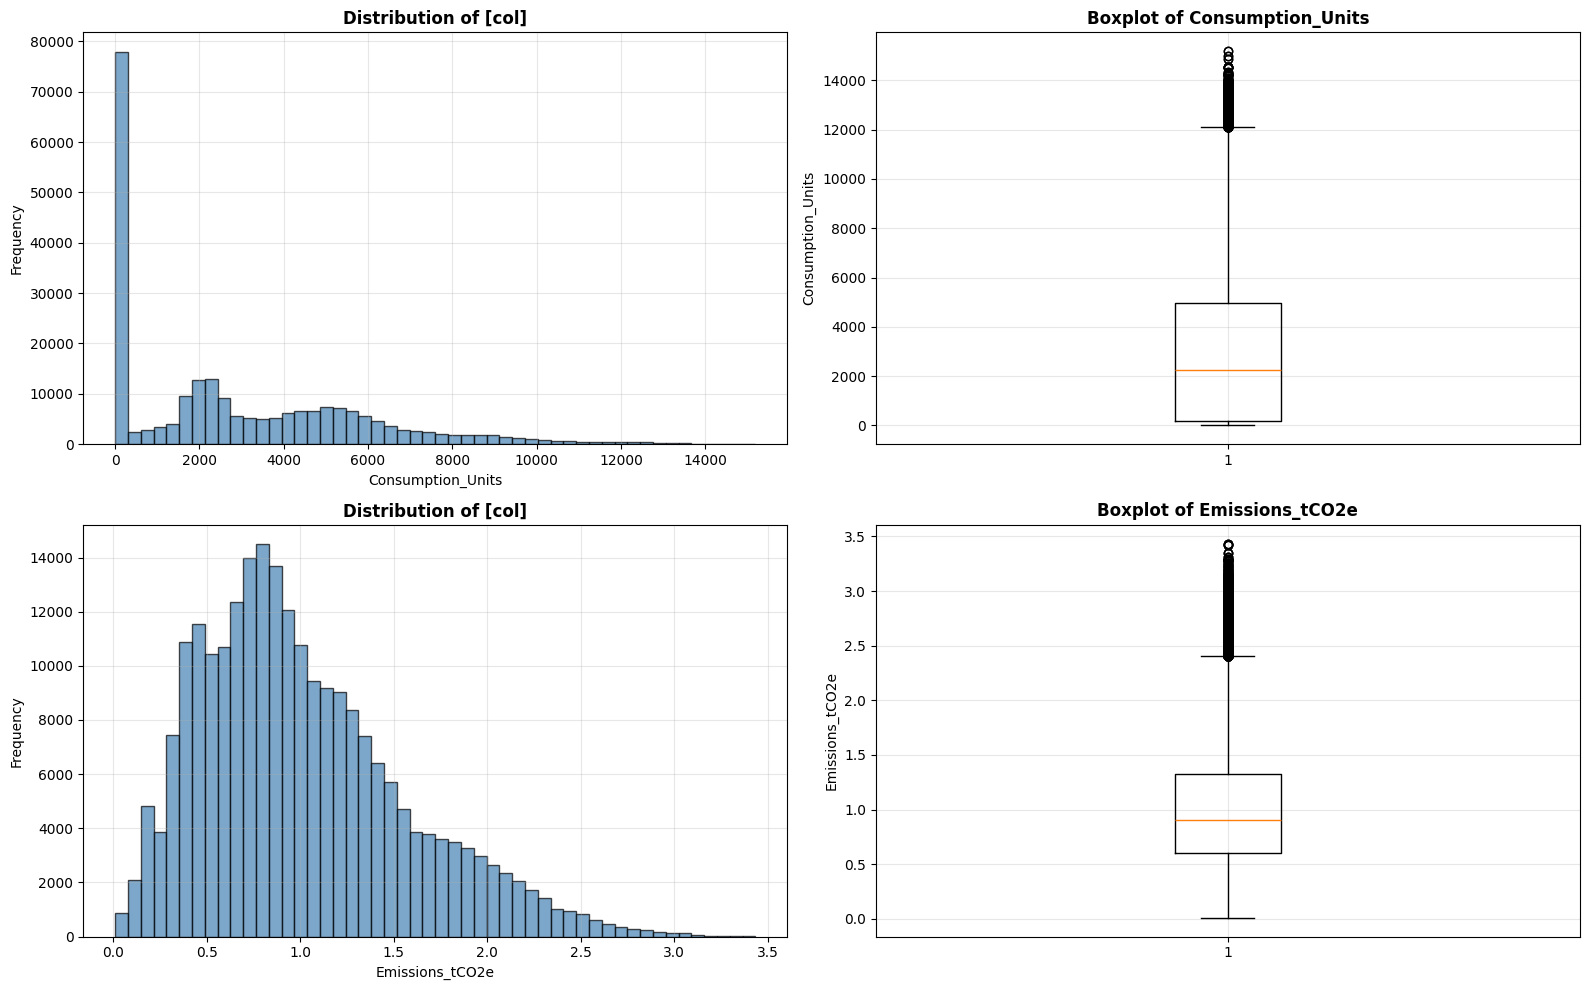

In [16]:
# check for distribution

numeric_cols = ['Consumption_Units', 'Emissions_tCO2e']

fig, axes = plt.subplots(2, 2, figsize=(16,10))

for idx, col in enumerate(numeric_cols):
    # Histogram
    axes[idx,0].hist(df[col], bins=50, edgecolor='black', alpha=0.7,color= 'steelblue')
    axes[idx,0].set_title(f'Distribution of [col]', fontsize=12, fontweight='bold')
    axes[idx,0].set_xlabel(col)
    axes[idx,0].set_ylabel('Frequency')
    axes[idx,0].grid(True, alpha=0.3)

    #Boxplot
    axes[idx, 1].boxplot(df[col], vert=True)
    axes[idx,1].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[idx,1].set_ylabel(col)
    axes[idx,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
df['Consumption_Units'].median()

np.float64(2251.237)

## Exploratory Data Analysis (EDA) is a crucial step in understanding the dataset before applying any machine learning models. 


<Axes: xlabel='Emission_Type'>

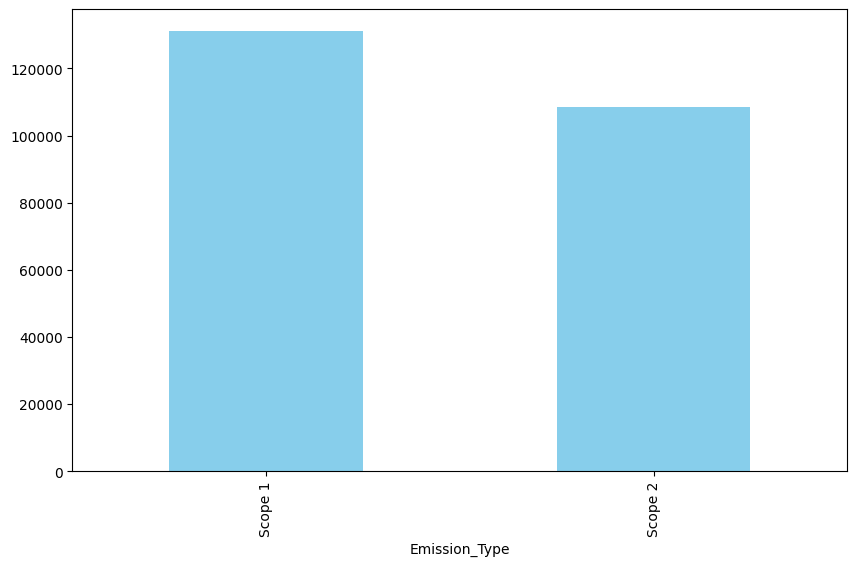

In [18]:
df.groupby('Emission_Type')['Emissions_tCO2e'].sum().sort_values(ascending=False).plot(kind='bar', figsize=(10, 6), color='skyblue')

## Time Series Analysis
### Understanding the trend of the data by 
- Daily
- Monthly
- Yearly

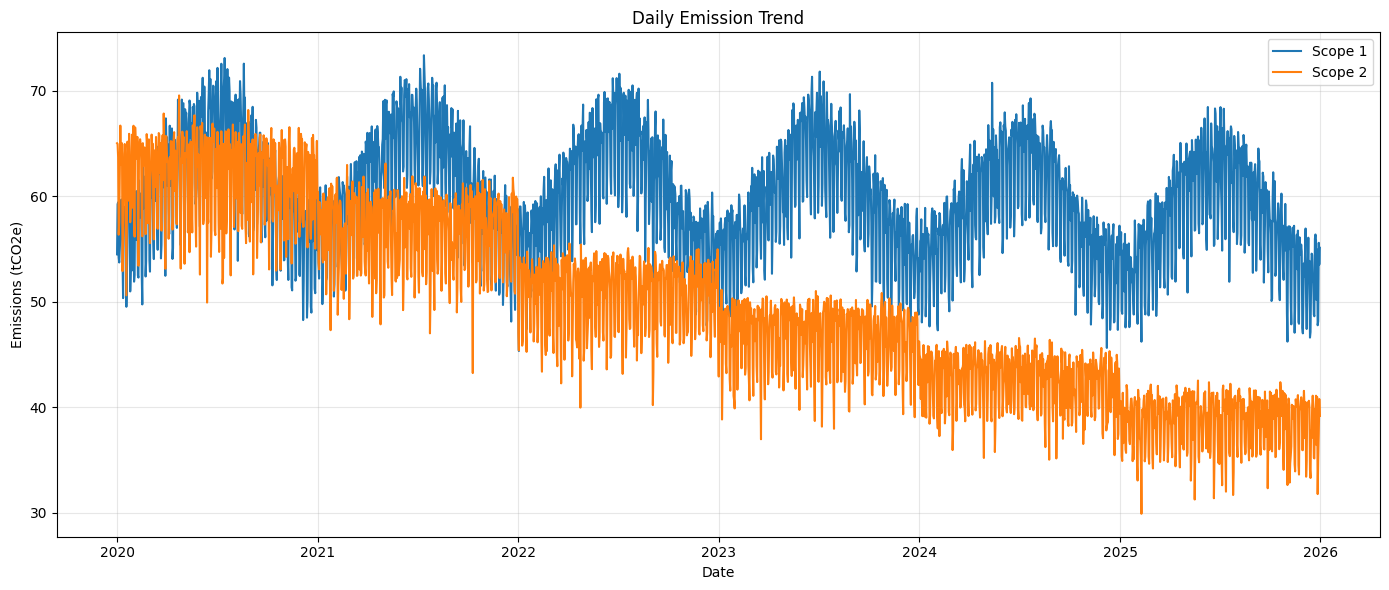

In [26]:
# Daily Emission Trend
daily_emissions= df.groupby(['Date','Emission_Type'])['Emissions_tCO2e'].sum().reset_index()

fig,axes = plt.subplots(figsize=(14,6))
for scope in ['Scope 1', 'Scope 2']:
    data = daily_emissions[daily_emissions['Emission_Type'] == scope]
    axes.plot(data['Date'], data['Emissions_tCO2e'], label=scope) 
axes.set_xlabel('Date')
axes.set_ylabel('Emissions (tCO2e)')
axes.set_title('Daily Emission Trend')
axes.legend()
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


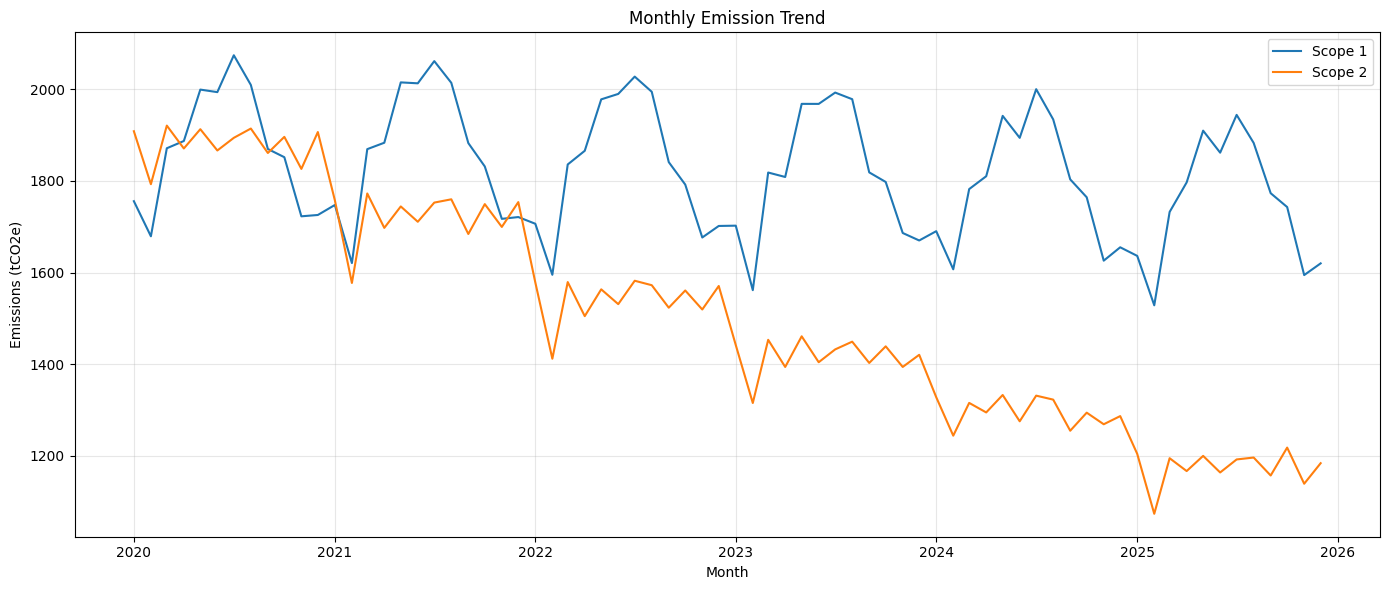

In [33]:
# check for the monthly trend
df['Month'] = df['Date'].dt.to_period('M')
monthly_emissions = df.groupby(['Month', 'Emission_Type'])['Emissions_tCO2e'].sum().reset_index()
monthly_emissions['Month'] = monthly_emissions['Month'].dt.to_timestamp()

fig,axes = plt.subplots(figsize=(14,6))
for scope in ['Scope 1', 'Scope 2']:
    data = monthly_emissions[monthly_emissions['Emission_Type'] == scope]
    axes.plot(data['Month'], data['Emissions_tCO2e'], label=scope) 
axes.set_xlabel('Month')
axes.set_ylabel('Emissions (tCO2e)')
axes.set_title('Monthly Emission Trend')
axes.legend()
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
#Yearly Emission Trend vs Target_Emissions
df[df['Energy_Type'] == 'DIESEL_L'][['Energy_Type', 'Target_Emissions_tCO2e']]


,Energy_Type,Target_Emissions_tCO2e
8768,DIESEL_L,15004.345
8769,DIESEL_L,15004.345
8770,DIESEL_L,15004.345
8771,DIESEL_L,15004.345
8772,DIESEL_L,15004.345
...,...,...
236731,DIESEL_L,11307.747
236732,DIESEL_L,11307.747
236733,DIESEL_L,11307.747
236734,DIESEL_L,11307.747


<Axes: xlabel='Year'>

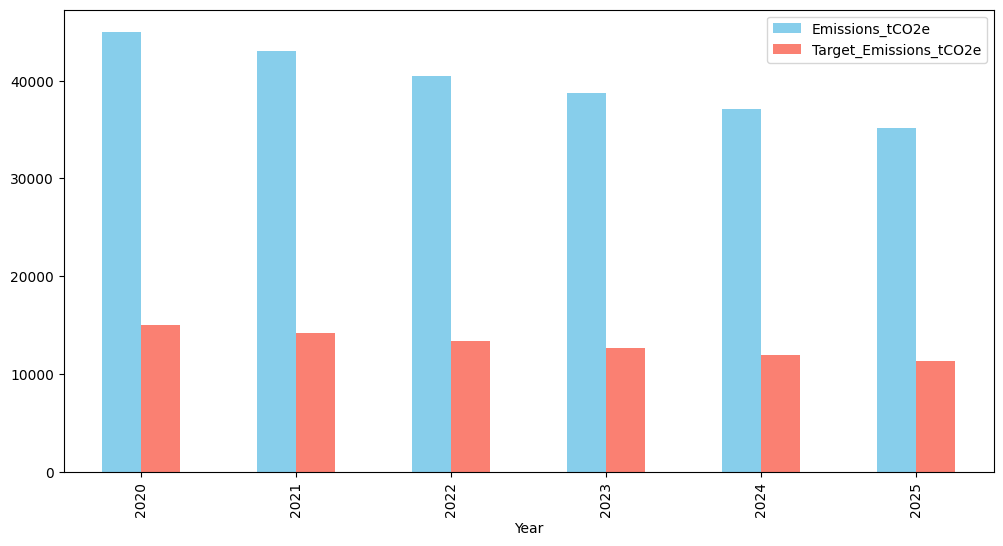

In [50]:
df.groupby('Year').agg({
    'Emissions_tCO2e': 'sum',
    'Target_Emissions_tCO2e': 'first'
}).reset_index().plot(x='Year', y=['Emissions_tCO2e', 'Target_Emissions_tCO2e'], kind='bar', figsize=(12, 6), color=['skyblue', 'salmon'])